# Scaling Diagnostics — TiedBayesMallows

Benchmarks how wall-clock time and MCMC quality metrics scale with the four
main problem dimensions:

| Symbol | Meaning |
|--------|---------|
| **N** | number of assessors (rankings) |
| **n** | number of items |
| **C** | number of clusters |
| **K** | avg. blocks per cluster |

Each section fixes all parameters except one and sweeps that dimension.
Section 7 adds joint (N, n) and (C, K) heatmaps; sections 8–9 examine
acceptance rates and ESS-per-second.

## 1 — Import Libraries & Setup

In [1]:
import sys, os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Make sure the package root is importable when running from this notebook's folder
sys.path.insert(0, os.path.dirname(os.path.abspath(".")))

from model import MixtureRankingModel, init_clusters_default
from model.initialization import init_spectral_with_z
from helper_functions.Generate_mixture_data import generate_mixture_data

warnings.filterwarnings("ignore", category=UserWarning)

# ── shared MCMC defaults ──────────────────────────────────────────────────────
N_ITER   = 200   # iterations per timing trial (kept short so the grid runs fast)
BURN_IN  = 50
THIN     = 1
SEED     = 42

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False,
                     "axes.spines.right": False})
print("Imports OK")

Imports OK


In [2]:
# ── helper: run one timed MCMC trial ─────────────────────────────────────────

def _make_blocks(n, n_blocks):
    """Partition items 0..n-1 into n_blocks roughly equal blocks."""
    items = list(range(n))
    return [items[i::n_blocks] for i in range(n_blocks)]


def run_trial(rankings, n_clusters, n_blocks_per_cluster=2,
              n_iter=N_ITER, burn_in=BURN_IN, seed=SEED):
    """
    Build a MixtureRankingModel, run MCMC, and return a result dict.

    Returns
    -------
    dict with keys:
        time_total_s      : total wall-clock for run_mcmc
        time_per_iter_ms  : ms per saved iteration
        n_saved           : number of saved samples
        theta_acc         : mean theta acceptance rate across clusters (or None)
        block_acc         : mean block acceptance rate across clusters (or None)
        mean_K            : mean blocks per cluster (from final state)
    """
    n  = len(rankings[0])
    N  = len(rankings)

    # Build init clusters: all-items-in-one-block start
    from model.dataclasses import ClusterParams
    init_clusters = [
        ClusterParams(blocks=_make_blocks(n, min(n_blocks_per_cluster, n)),
                      theta=1.0, gamma=1.0, delta=0.5)
        for _ in range(n_clusters)
    ]
    rng = np.random.default_rng(seed)
    init_z = [int(rng.integers(0, n_clusters)) for _ in range(N)]

    model = MixtureRankingModel(
        rankings,
        init_clusters=init_clusters,
        init_z=init_z,
        seed=seed,
    )

    t0 = time.perf_counter()
    final_state, samples = model.run_mcmc(n_iter, burn_in=burn_in, thin=1)
    t1 = time.perf_counter()

    elapsed   = t1 - t0
    n_saved   = len(samples.z_samples)
    per_iter  = elapsed / max(n_saved, 1) * 1000  # ms per saved sample

    # acceptance stats
    acc = model.acceptance_statistics()
    theta_acc = None
    block_acc = None
    if "theta" in acc:
        rates = [x["acceptance_rate"] for x in acc["theta"]["per_cluster"]
                 if x["acceptance_rate"] is not None]
        theta_acc = float(np.mean(rates)) if rates else None
    if "blocks" in acc:
        rates = [x["acceptance_rate"] for x in acc["blocks"]["per_cluster"]
                 if x["acceptance_rate"] is not None]
        block_acc = float(np.mean(rates)) if rates else None

    mean_K = float(np.mean([len(cl.blocks) for cl in final_state.clusters]))

    return dict(
        time_total_s=elapsed,
        time_per_iter_ms=per_iter,
        n_saved=n_saved,
        theta_acc=theta_acc,
        block_acc=block_acc,
        mean_K=mean_K,
    )


print("Helper functions defined")

Helper functions defined


## 2 — Scaling with N (Number of Assessors)

In [3]:
N_GRID = [25, 50, 100, 200, 500, 1000]
FIXED_n = 8
FIXED_C = 2
FIXED_K = 2  # initial blocks per cluster

rows_N = []
for N_val in N_GRID:
    rng = np.random.default_rng(SEED)
    rankings = [list(rng.permutation(FIXED_n)) for _ in range(N_val)]
    r = run_trial(rankings, n_clusters=FIXED_C, n_blocks_per_cluster=FIXED_K)
    r["N"] = N_val
    rows_N.append(r)
    print(f"N={N_val:5d}  {r['time_per_iter_ms']:.2f} ms/iter  "
          f"block_acc={r['block_acc']:.2%}  theta_acc={r['theta_acc']:.2%}")

df_N = pd.DataFrame(rows_N)
print("\nDone")

N=   25  0.34 ms/iter  block_acc=0.00%  theta_acc=45.00%
N=   50  0.47 ms/iter  block_acc=71.00%  theta_acc=52.00%
N=  100  0.36 ms/iter  block_acc=1.33%  theta_acc=48.67%
N=  200  0.63 ms/iter  block_acc=40.67%  theta_acc=68.67%
N=  500  0.78 ms/iter  block_acc=32.67%  theta_acc=67.33%
N= 1000  1.63 ms/iter  block_acc=2.67%  theta_acc=87.67%

Done


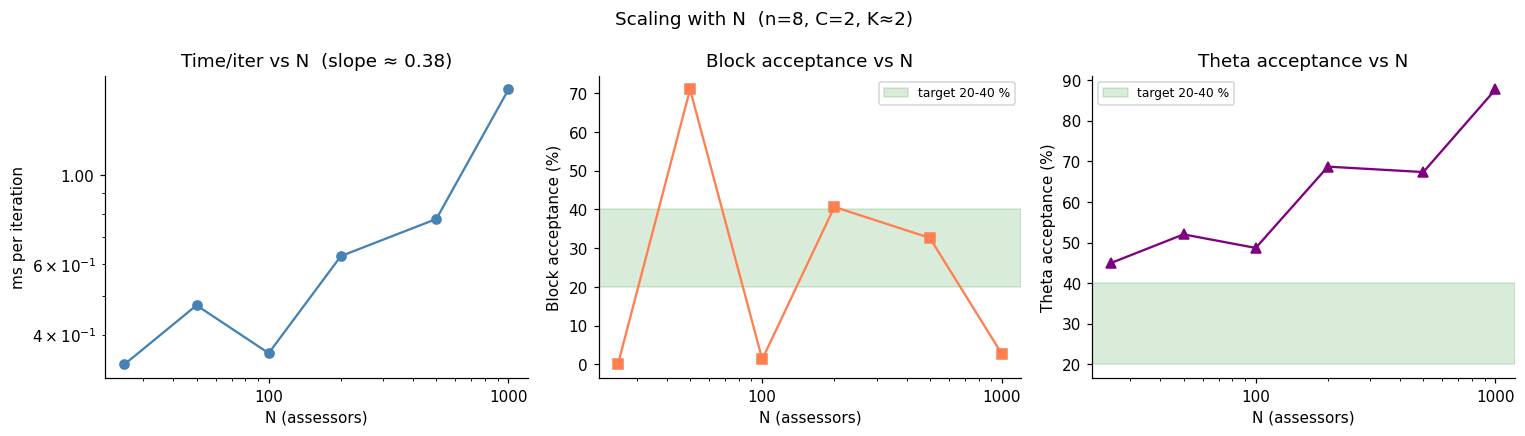

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# — time per iteration —
ax = axes[0]
ax.loglog(df_N["N"], df_N["time_per_iter_ms"], "o-", color="steelblue")
# fit OLS in log-log space
x = np.log(df_N["N"].values.astype(float))
y = np.log(df_N["time_per_iter_ms"].values)
slope, intercept = np.polyfit(x, y, 1)
ax.set_title(f"Time/iter vs N  (slope ≈ {slope:.2f})")
ax.set_xlabel("N (assessors)")
ax.set_ylabel("ms per iteration")
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.yaxis.set_major_formatter(mticker.ScalarFormatter())

# — block acceptance rate —
ax = axes[1]
ax.semilogx(df_N["N"], [v * 100 for v in df_N["block_acc"]], "s-", color="coral")
ax.axhspan(20, 40, alpha=0.15, color="green", label="target 20-40 %")
ax.set_title("Block acceptance vs N")
ax.set_xlabel("N (assessors)")
ax.set_ylabel("Block acceptance (%)")
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())

# — theta acceptance rate —
ax = axes[2]
ax.semilogx(df_N["N"], [v * 100 for v in df_N["theta_acc"]], "^-", color="purple")
ax.axhspan(20, 40, alpha=0.15, color="green", label="target 20-40 %")
ax.set_title("Theta acceptance vs N")
ax.set_xlabel("N (assessors)")
ax.set_ylabel("Theta acceptance (%)")
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())

fig.suptitle(f"Scaling with N  (n={FIXED_n}, C={FIXED_C}, K≈{FIXED_K})", fontsize=12)
fig.tight_layout()
plt.show()

## 3 — Scaling with n (Number of Items)

In [5]:
n_GRID = [4, 6, 8, 12, 16, 24, 32]
FIXED_N = 100
FIXED_C = 2
FIXED_K = 2

rows_n = []
for n_val in n_GRID:
    rng = np.random.default_rng(SEED)
    rankings = [list(rng.permutation(n_val)) for _ in range(FIXED_N)]
    r = run_trial(rankings, n_clusters=FIXED_C, n_blocks_per_cluster=FIXED_K)
    r["n"] = n_val
    rows_n.append(r)
    print(f"n={n_val:3d}  {r['time_per_iter_ms']:.2f} ms/iter  "
          f"block_acc={r['block_acc']:.2%}  theta_acc={r['theta_acc']:.2%}")

df_n = pd.DataFrame(rows_n)
print("\nDone")

n=  4  0.57 ms/iter  block_acc=38.00%  theta_acc=77.67%
n=  6  0.53 ms/iter  block_acc=33.00%  theta_acc=79.33%
n=  8  0.36 ms/iter  block_acc=1.33%  theta_acc=48.67%
n= 12  0.36 ms/iter  block_acc=0.00%  theta_acc=42.67%
n= 16  0.39 ms/iter  block_acc=0.33%  theta_acc=44.33%
n= 24  0.50 ms/iter  block_acc=8.00%  theta_acc=40.67%
n= 32  0.53 ms/iter  block_acc=42.00%  theta_acc=35.67%

Done


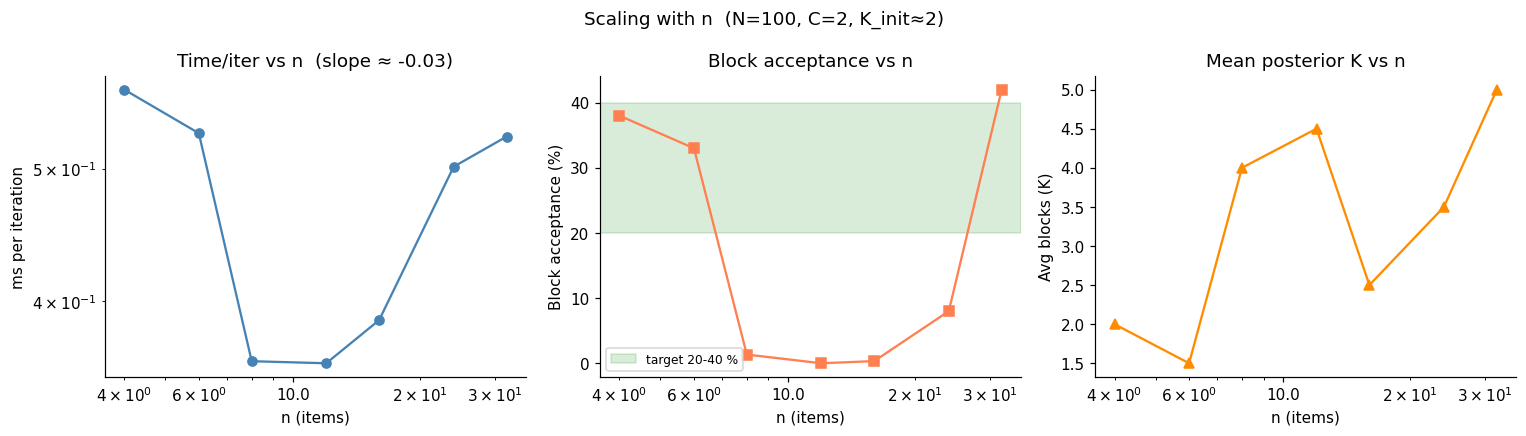

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
ax.loglog(df_n["n"], df_n["time_per_iter_ms"], "o-", color="steelblue")
x = np.log(df_n["n"].values.astype(float))
y = np.log(df_n["time_per_iter_ms"].values)
slope, _ = np.polyfit(x, y, 1)
ax.set_title(f"Time/iter vs n  (slope ≈ {slope:.2f})")
ax.set_xlabel("n (items)")
ax.set_ylabel("ms per iteration")
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.yaxis.set_major_formatter(mticker.ScalarFormatter())

ax = axes[1]
ax.semilogx(df_n["n"], [v * 100 for v in df_n["block_acc"]], "s-", color="coral")
ax.axhspan(20, 40, alpha=0.15, color="green", label="target 20-40 %")
ax.set_title("Block acceptance vs n")
ax.set_xlabel("n (items)")
ax.set_ylabel("Block acceptance (%)")
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())

ax = axes[2]
ax.semilogx(df_n["n"], df_n["mean_K"], "^-", color="darkorange")
ax.set_title("Mean posterior K vs n")
ax.set_xlabel("n (items)")
ax.set_ylabel("Avg blocks (K)")
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())

fig.suptitle(f"Scaling with n  (N={FIXED_N}, C={FIXED_C}, K_init≈{FIXED_K})", fontsize=12)
fig.tight_layout()
plt.show()

## 4 — Scaling with C (Number of Clusters)

In [7]:
C_GRID  = [1, 2, 3, 5, 8, 12]
FIXED_N = 100
FIXED_n = 8
FIXED_K = 2

rows_C = []
for C_val in C_GRID:
    rng = np.random.default_rng(SEED)
    rankings = [list(rng.permutation(FIXED_n)) for _ in range(FIXED_N)]
    r = run_trial(rankings, n_clusters=C_val, n_blocks_per_cluster=FIXED_K)
    r["C"] = C_val
    rows_C.append(r)
    print(f"C={C_val:3d}  {r['time_per_iter_ms']:.2f} ms/iter  "
          f"block_acc={r['block_acc']:.2%}  theta_acc={r['theta_acc']:.2%}")

df_C = pd.DataFrame(rows_C)
print("\nDone")

C=  1  0.32 ms/iter  block_acc=0.00%  theta_acc=90.00%
C=  2  0.50 ms/iter  block_acc=1.33%  theta_acc=48.67%
C=  3  0.51 ms/iter  block_acc=3.11%  theta_acc=33.33%
C=  5  1.28 ms/iter  block_acc=36.13%  theta_acc=48.27%
C=  8  1.77 ms/iter  block_acc=53.92%  theta_acc=42.17%
C= 12  1.84 ms/iter  block_acc=39.56%  theta_acc=35.28%

Done


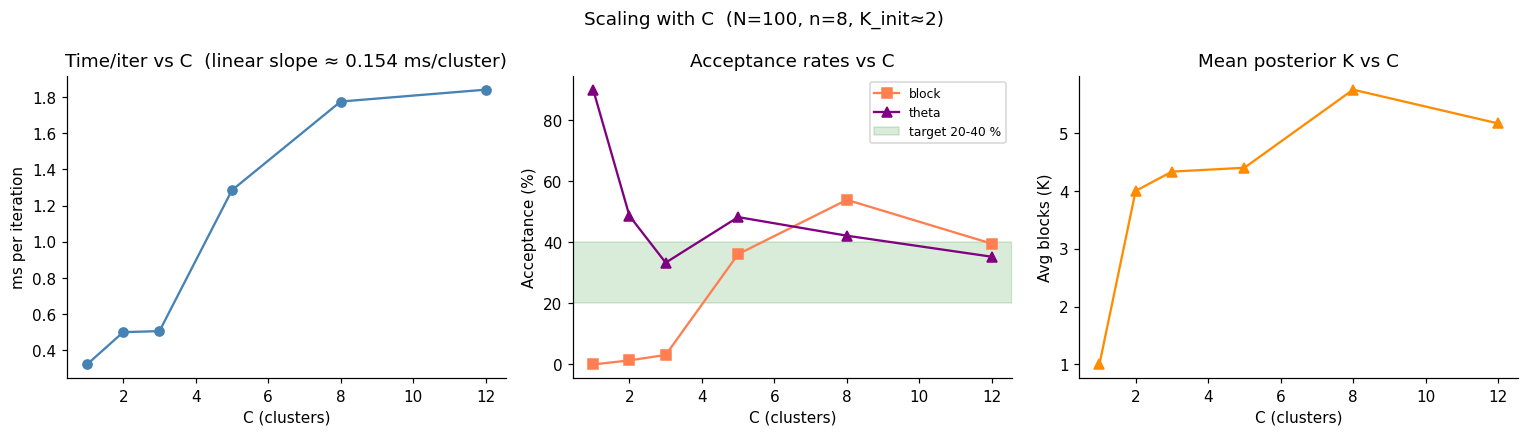

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
ax.plot(df_C["C"], df_C["time_per_iter_ms"], "o-", color="steelblue")
x = df_C["C"].values.astype(float)
y = df_C["time_per_iter_ms"].values
slope, _ = np.polyfit(x, y, 1)
ax.set_title(f"Time/iter vs C  (linear slope ≈ {slope:.3f} ms/cluster)")
ax.set_xlabel("C (clusters)")
ax.set_ylabel("ms per iteration")

ax = axes[1]
ax.plot(df_C["C"], [v * 100 for v in df_C["block_acc"]], "s-", color="coral", label="block")
ax.plot(df_C["C"], [v * 100 for v in df_C["theta_acc"]], "^-", color="purple", label="theta")
ax.axhspan(20, 40, alpha=0.15, color="green", label="target 20-40 %")
ax.set_title("Acceptance rates vs C")
ax.set_xlabel("C (clusters)")
ax.set_ylabel("Acceptance (%)")
ax.legend(fontsize=8)

ax = axes[2]
ax.plot(df_C["C"], df_C["mean_K"], "^-", color="darkorange")
ax.set_title("Mean posterior K vs C")
ax.set_xlabel("C (clusters)")
ax.set_ylabel("Avg blocks (K)")

fig.suptitle(f"Scaling with C  (N={FIXED_N}, n={FIXED_n}, K_init≈{FIXED_K})", fontsize=12)
fig.tight_layout()
plt.show()

## 5 — Scaling with K (Initial Blocks per Cluster)

In [9]:
FIXED_N_k = 100
FIXED_n_k = 16   # need n large enough for many blocks
FIXED_C_k = 2
K_GRID    = [1, 2, 4, 6, 8, 12, 16]   # initial blocks per cluster (capped at n)

rows_K = []
for K_val in K_GRID:
    K_eff = min(K_val, FIXED_n_k)
    rng = np.random.default_rng(SEED)
    rankings = [list(rng.permutation(FIXED_n_k)) for _ in range(FIXED_N_k)]
    r = run_trial(rankings, n_clusters=FIXED_C_k, n_blocks_per_cluster=K_eff)
    r["K_init"] = K_eff
    rows_K.append(r)
    print(f"K_init={K_eff:3d}  K_final≈{r['mean_K']:.1f}  "
          f"{r['time_per_iter_ms']:.2f} ms/iter  block_acc={r['block_acc']:.2%}")

df_K = pd.DataFrame(rows_K)
print("\nDone")

K_init=  1  K_final≈4.5  0.61 ms/iter  block_acc=13.33%
K_init=  2  K_final≈2.5  0.41 ms/iter  block_acc=0.33%
K_init=  4  K_final≈7.5  0.63 ms/iter  block_acc=86.67%
K_init=  6  K_final≈5.0  0.47 ms/iter  block_acc=46.67%
K_init=  8  K_final≈5.0  0.44 ms/iter  block_acc=41.00%
K_init= 12  K_final≈6.5  0.40 ms/iter  block_acc=29.00%
K_init= 16  K_final≈6.5  0.44 ms/iter  block_acc=42.00%

Done


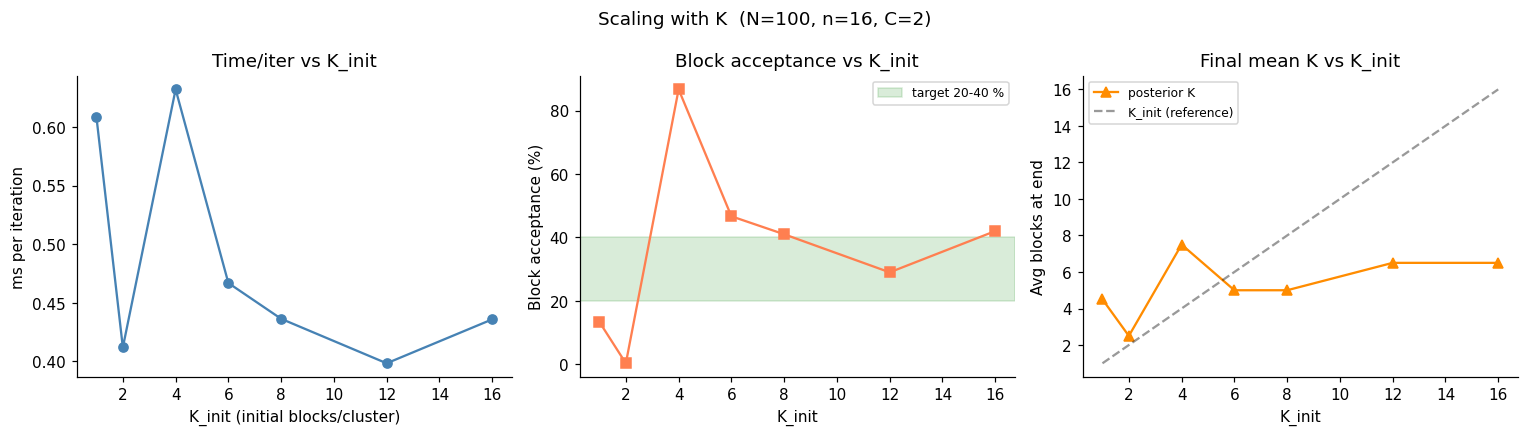

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
ax.plot(df_K["K_init"], df_K["time_per_iter_ms"], "o-", color="steelblue")
ax.set_title("Time/iter vs K_init")
ax.set_xlabel("K_init (initial blocks/cluster)")
ax.set_ylabel("ms per iteration")

ax = axes[1]
ax.plot(df_K["K_init"], [v * 100 for v in df_K["block_acc"]], "s-", color="coral")
ax.axhspan(20, 40, alpha=0.15, color="green", label="target 20-40 %")
ax.set_title("Block acceptance vs K_init")
ax.set_xlabel("K_init")
ax.set_ylabel("Block acceptance (%)")
ax.legend(fontsize=8)

ax = axes[2]
ax.plot(df_K["K_init"], df_K["mean_K"], "^-", color="darkorange", label="posterior K")
ax.plot(df_K["K_init"], df_K["K_init"], "k--", alpha=0.4, label="K_init (reference)")
ax.set_title("Final mean K vs K_init")
ax.set_xlabel("K_init")
ax.set_ylabel("Avg blocks at end")
ax.legend(fontsize=8)

fig.suptitle(f"Scaling with K  (N={FIXED_N_k}, n={FIXED_n_k}, C={FIXED_C_k})", fontsize=12)
fig.tight_layout()
plt.show()

## 6 — Joint Scaling Heatmaps (N × n and C × K)

Each cell runs a short MCMC trial; colour = ms per iteration.
These grids take a few minutes — reduce the grid sizes at the top if you need to go faster.

In [11]:
# ── N × n heatmap ─────────────────────────────────────────────────────────────
HM_N_GRID = [25, 100, 300, 800]
HM_n_GRID = [5,  8,   12,  20 ]
HM_C = 2
HM_K = 2

grid_Nn = np.zeros((len(HM_N_GRID), len(HM_n_GRID)))
for i, N_val in enumerate(HM_N_GRID):
    for j, n_val in enumerate(HM_n_GRID):
        rng = np.random.default_rng(SEED)
        rankings = [list(rng.permutation(n_val)) for _ in range(N_val)]
        r = run_trial(rankings, n_clusters=HM_C, n_blocks_per_cluster=HM_K,
                      n_iter=100, burn_in=20)
        grid_Nn[i, j] = r["time_per_iter_ms"]
        print(f"  N={N_val:4d} n={n_val:3d}  {r['time_per_iter_ms']:.2f} ms/iter")

# ── C × K heatmap ─────────────────────────────────────────────────────────────
HM_C_GRID = [2, 4, 6, 10]
HM_K_GRID = [1, 2, 4, 8]   # initial blocks per cluster (n must be >= K)
HM_N2 = 100
HM_n2 = 16

grid_CK = np.zeros((len(HM_C_GRID), len(HM_K_GRID)))
for i, C_val in enumerate(HM_C_GRID):
    for j, K_val in enumerate(HM_K_GRID):
        rng = np.random.default_rng(SEED)
        rankings = [list(rng.permutation(HM_n2)) for _ in range(HM_N2)]
        r = run_trial(rankings, n_clusters=C_val, n_blocks_per_cluster=K_val,
                      n_iter=100, burn_in=20)
        grid_CK[i, j] = r["time_per_iter_ms"]
        print(f"  C={C_val:3d} K={K_val:2d}  {r['time_per_iter_ms']:.2f} ms/iter")

print("\nDone")

  N=  25 n=  5  0.56 ms/iter
  N=  25 n=  8  0.32 ms/iter
  N=  25 n= 12  0.34 ms/iter
  N=  25 n= 20  0.34 ms/iter
  N= 100 n=  5  0.55 ms/iter
  N= 100 n=  8  0.37 ms/iter
  N= 100 n= 12  0.36 ms/iter
  N= 100 n= 20  0.65 ms/iter
  N= 300 n=  5  0.64 ms/iter
  N= 300 n=  8  0.63 ms/iter
  N= 300 n= 12  0.59 ms/iter
  N= 300 n= 20  0.56 ms/iter
  N= 800 n=  5  0.92 ms/iter
  N= 800 n=  8  1.01 ms/iter
  N= 800 n= 12  0.79 ms/iter
  N= 800 n= 20  0.89 ms/iter
  C=  2 K= 1  0.46 ms/iter
  C=  2 K= 2  0.37 ms/iter
  C=  2 K= 4  0.57 ms/iter
  C=  2 K= 8  0.45 ms/iter
  C=  4 K= 1  0.71 ms/iter
  C=  4 K= 2  0.47 ms/iter
  C=  4 K= 4  0.64 ms/iter
  C=  4 K= 8  0.89 ms/iter
  C=  6 K= 1  0.95 ms/iter
  C=  6 K= 2  1.37 ms/iter
  C=  6 K= 4  1.04 ms/iter
  C=  6 K= 8  1.23 ms/iter
  C= 10 K= 1  1.25 ms/iter
  C= 10 K= 2  1.18 ms/iter
  C= 10 K= 4  2.02 ms/iter
  C= 10 K= 8  0.84 ms/iter

Done


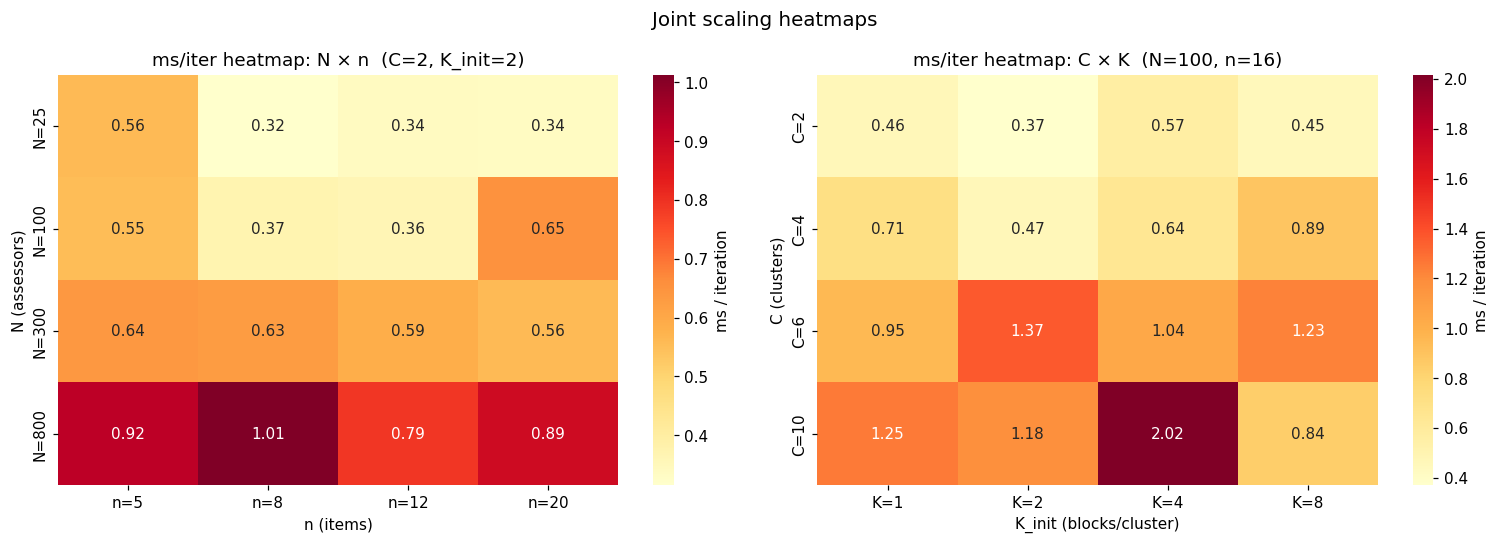

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
df_Nn_heat = pd.DataFrame(grid_Nn,
    index=[f"N={v}" for v in HM_N_GRID],
    columns=[f"n={v}" for v in HM_n_GRID])
sns.heatmap(df_Nn_heat, ax=ax, annot=True, fmt=".2f", cmap="YlOrRd",
            cbar_kws={"label": "ms / iteration"})
ax.set_title(f"ms/iter heatmap: N × n  (C={HM_C}, K_init={HM_K})")
ax.set_xlabel("n (items)")
ax.set_ylabel("N (assessors)")

ax = axes[1]
df_CK_heat = pd.DataFrame(grid_CK,
    index=[f"C={v}" for v in HM_C_GRID],
    columns=[f"K={v}" for v in HM_K_GRID])
sns.heatmap(df_CK_heat, ax=ax, annot=True, fmt=".2f", cmap="YlOrRd",
            cbar_kws={"label": "ms / iteration"})
ax.set_title(f"ms/iter heatmap: C × K  (N={HM_N2}, n={HM_n2})")
ax.set_xlabel("K_init (blocks/cluster)")
ax.set_ylabel("C (clusters)")

fig.suptitle("Joint scaling heatmaps", fontsize=13)
fig.tight_layout()
plt.show()

## 7 — MCMC Quality: ESS and Autocorrelation vs Scale

ESS (effective sample size) is estimated from the theta chain of the first cluster.
A manual batch-means estimator is used to avoid the `arviz` dependency, but
`arviz` is used if available for a more rigorous estimate.

In [15]:
def _ess_batch_means(chain, n_batches=10):
    """Simple batch-means ESS estimator. chain: 1-D array."""
    T = len(chain)
    if T < 2 * n_batches:
        return float("nan")
    b = T // n_batches
    means = [np.mean(chain[i*b:(i+1)*b]) for i in range(n_batches)]
    var_between = np.var(means, ddof=1) * b
    var_total   = np.var(chain, ddof=1)
    if var_between <= 0:
        return float("nan")
    return T * var_total / var_between


def _lag1_autocorr(chain):
    """Lag-1 autocorrelation of a 1-D array."""
    if len(chain) < 3:
        return float("nan")
    c = chain - np.mean(chain)
    return float(np.dot(c[:-1], c[1:]) / (np.dot(c, c) + 1e-12))


def run_trial_ess(rankings, n_clusters, n_blocks_per_cluster=2,
                  n_iter=500, burn_in=100, seed=SEED):
    """Like run_trial but saves theta and returns ESS / lag-1 autocorrelation for theta[0]."""
    from model.dataclasses import ClusterParams
    n = len(rankings[0])
    N = len(rankings)

    init_clusters = [
        ClusterParams(blocks=_make_blocks(n, min(n_blocks_per_cluster, n)),
                      theta=1.0, gamma=1.0, delta=0.5)
        for _ in range(n_clusters)
    ]
    rng0 = np.random.default_rng(seed)
    init_z = [int(rng0.integers(0, n_clusters)) for _ in range(N)]

    model = MixtureRankingModel(rankings, init_clusters=init_clusters,
                                init_z=init_z, seed=seed)

    t0 = time.perf_counter()
    _, samples = model.run_mcmc(n_iter, burn_in=burn_in, thin=1, save_theta=True)
    elapsed = time.perf_counter() - t0

    n_saved = len(samples.z_samples)

    # theta chain for cluster 0 — samples.theta_samples is list[list[float]], shape [T][C]
    if samples.theta_samples:
        theta_chain = np.array([row[0] for row in samples.theta_samples])
    else:
        theta_chain = np.full(n_saved, float("nan"))

    ess   = _ess_batch_means(theta_chain)
    rho1  = _lag1_autocorr(theta_chain)
    ess_s = ess / elapsed if np.isfinite(ess) and elapsed > 0 else float("nan")

    return dict(
        time_total_s=elapsed,
        time_per_iter_ms=elapsed / max(n_saved, 1) * 1000,
        ess=ess,
        ess_per_second=ess_s,
        lag1_autocorr=rho1,
    )


print("ESS helpers defined")

ESS helpers defined


In [16]:
# Run ESS trials across N and n
ESS_N_GRID = [25, 50, 100, 200, 500]
ESS_n_GRID = [4, 6, 8, 12, 16, 24]

rows_ess_N = []
for N_val in ESS_N_GRID:
    rng = np.random.default_rng(SEED)
    rankings = [list(rng.permutation(FIXED_n)) for _ in range(N_val)]
    r = run_trial_ess(rankings, n_clusters=2)
    r["N"] = N_val
    rows_ess_N.append(r)
    print(f"N={N_val:5d}  ESS={r['ess']:.0f}  ESS/s={r['ess_per_second']:.1f}  ρ₁={r['lag1_autocorr']:.3f}")

rows_ess_n = []
for n_val in ESS_n_GRID:
    rng = np.random.default_rng(SEED)
    rankings = [list(rng.permutation(n_val)) for _ in range(FIXED_N)]
    r = run_trial_ess(rankings, n_clusters=2)
    r["n"] = n_val
    rows_ess_n.append(r)
    print(f"n={n_val:3d}  ESS={r['ess']:.0f}  ESS/s={r['ess_per_second']:.1f}  ρ₁={r['lag1_autocorr']:.3f}")

df_ess_N = pd.DataFrame(rows_ess_N)
df_ess_n = pd.DataFrame(rows_ess_n)
print("\nDone")

N=   25  ESS=15  ESS/s=124.2  ρ₁=0.952
N=   50  ESS=36  ESS/s=239.3  ρ₁=0.945
N=  100  ESS=10  ESS/s=41.7  ρ₁=0.992
N=  200  ESS=10  ESS/s=55.2  ρ₁=0.986
N=  500  ESS=11  ESS/s=35.1  ρ₁=0.984
n=  4  ESS=13  ESS/s=64.5  ρ₁=0.960
n=  6  ESS=16  ESS/s=77.5  ρ₁=0.952
n=  8  ESS=10  ESS/s=70.4  ρ₁=0.992
n= 12  ESS=nan  ESS/s=nan  ρ₁=0.000
n= 16  ESS=10  ESS/s=70.2  ρ₁=0.976
n= 24  ESS=23  ESS/s=144.5  ρ₁=0.941

Done


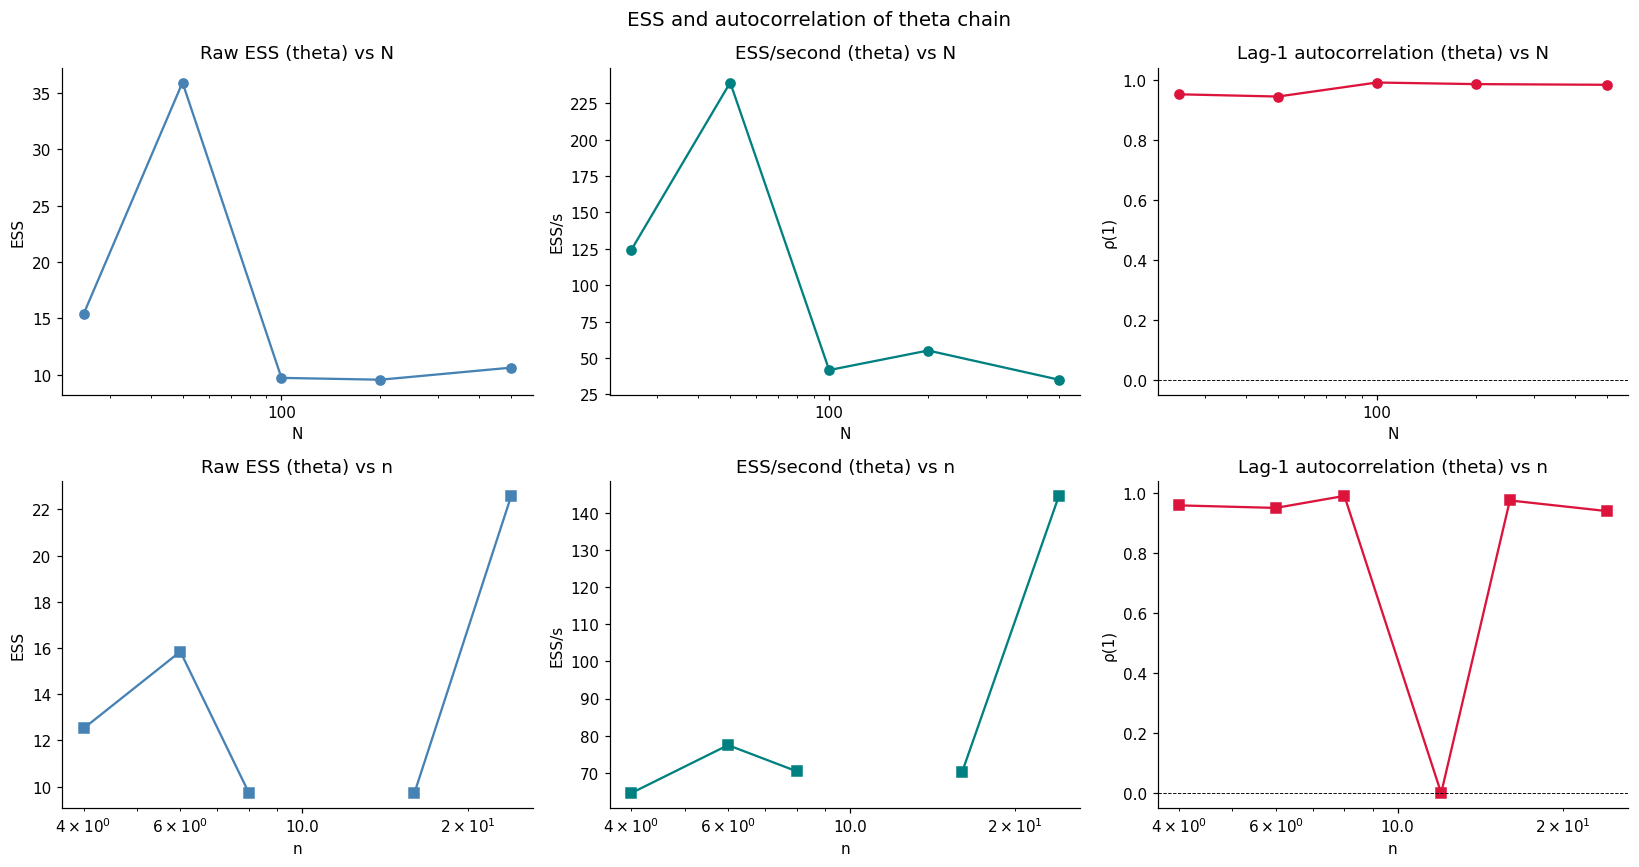

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Row 0: vs N
ax = axes[0, 0]
ax.semilogx(df_ess_N["N"], df_ess_N["ess"], "o-", color="steelblue")
ax.set_title("Raw ESS (theta) vs N")
ax.set_xlabel("N"); ax.set_ylabel("ESS")
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())

ax = axes[0, 1]
ax.semilogx(df_ess_N["N"], df_ess_N["ess_per_second"], "o-", color="teal")
ax.set_title("ESS/second (theta) vs N")
ax.set_xlabel("N"); ax.set_ylabel("ESS/s")
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())

ax = axes[0, 2]
ax.semilogx(df_ess_N["N"], df_ess_N["lag1_autocorr"], "o-", color="crimson")
ax.axhline(0, color="k", linewidth=0.6, linestyle="--")
ax.set_title("Lag-1 autocorrelation (theta) vs N")
ax.set_xlabel("N"); ax.set_ylabel("ρ(1)")
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())

# Row 1: vs n
ax = axes[1, 0]
ax.semilogx(df_ess_n["n"], df_ess_n["ess"], "s-", color="steelblue")
ax.set_title("Raw ESS (theta) vs n")
ax.set_xlabel("n"); ax.set_ylabel("ESS")
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())

ax = axes[1, 1]
ax.semilogx(df_ess_n["n"], df_ess_n["ess_per_second"], "s-", color="teal")
ax.set_title("ESS/second (theta) vs n")
ax.set_xlabel("n"); ax.set_ylabel("ESS/s")
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())

ax = axes[1, 2]
ax.semilogx(df_ess_n["n"], df_ess_n["lag1_autocorr"], "s-", color="crimson")
ax.axhline(0, color="k", linewidth=0.6, linestyle="--")
ax.set_title("Lag-1 autocorrelation (theta) vs n")
ax.set_xlabel("n"); ax.set_ylabel("ρ(1)")
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())

fig.suptitle("ESS and autocorrelation of theta chain", fontsize=13)
fig.tight_layout()
plt.show()

## 8 — Summary Table

Collects the key numbers from all sweeps into one DataFrame for quick reference.

In [18]:
def _summarise(df, dim_col):
    cols = [dim_col, "time_per_iter_ms"]
    if "block_acc" in df.columns:
        cols += ["block_acc", "theta_acc"]
    if "mean_K" in df.columns:
        cols.append("mean_K")
    if "ess_per_second" in df.columns:
        cols += ["ess_per_second", "lag1_autocorr"]
    sub = df[cols].copy()
    if "block_acc" in sub.columns:
        sub["block_acc"] = sub["block_acc"].map(lambda v: f"{v:.1%}" if v is not None else "-")
    if "theta_acc" in sub.columns:
        sub["theta_acc"] = sub["theta_acc"].map(lambda v: f"{v:.1%}" if v is not None else "-")
    return sub

print("=== Scaling with N ===")
display(_summarise(df_N, "N"))
print("\n=== Scaling with n ===")
display(_summarise(df_n, "n"))
print("\n=== Scaling with C ===")
display(_summarise(df_C, "C"))
print("\n=== Scaling with K ===")
display(_summarise(df_K.rename(columns={"K_init": "K"}), "K"))

=== Scaling with N ===


,N,time_per_iter_ms,block_acc,theta_acc,mean_K
0,25,0.336982,0.0%,45.0%,2.5
1,50,0.473248,71.0%,52.0%,7.5
2,100,0.359523,1.3%,48.7%,4.0
3,200,0.627795,40.7%,68.7%,3.5
4,500,0.776732,32.7%,67.3%,2.5
5,1000,1.634636,2.7%,87.7%,2.5



=== Scaling with n ===


,n,time_per_iter_ms,block_acc,theta_acc,mean_K
0,4,0.571425,38.0%,77.7%,2.0
1,6,0.530972,33.0%,79.3%,1.5
2,8,0.361641,1.3%,48.7%,4.0
3,12,0.360399,0.0%,42.7%,4.5
4,16,0.387555,0.3%,44.3%,2.5
5,24,0.501833,8.0%,40.7%,3.5
6,32,0.527932,42.0%,35.7%,5.0



=== Scaling with C ===


,C,time_per_iter_ms,block_acc,theta_acc,mean_K
0,1,0.322272,0.0%,90.0%,1.000000
1,2,0.500801,1.3%,48.7%,4.000000
2,3,0.506381,3.1%,33.3%,4.333333
3,5,1.284895,36.1%,48.3%,4.400000
4,8,1.774641,53.9%,42.2%,5.750000
5,12,1.840157,39.6%,35.3%,5.166667



=== Scaling with K ===


,K,time_per_iter_ms,block_acc,theta_acc,mean_K
0,1,0.608437,13.3%,60.0%,4.5
1,2,0.411970,0.3%,44.3%,2.5
2,4,0.632231,86.7%,62.3%,7.5
3,6,0.466947,46.7%,32.7%,5.0
4,8,0.436397,41.0%,34.0%,5.0
5,12,0.398438,29.0%,35.0%,6.5
6,16,0.435939,42.0%,34.7%,6.5


## 9. Analytical Resource Estimates for Large-Scale Configurations

The measured `n` sweep (n = 4–32) looked essentially flat because `n_pairs = C(n,2)` was tiny (6–496) and the O(N · n² · C) matmul was negligible. At **n = 1200 the quadratic term explodes**: `n_pairs = 719,400` (≈ 1,450× larger than n = 32).

Below we compute analytical upper-bound estimates for arbitrary (N, n, C) **without running the model**.

Key cost drivers per MCMC iteration:
1. `U_all @ M.T` matmul — shape (N, n_pairs) @ (n_pairs, C) — dominates time
2. `U_all[mask].sum(axis=0)` per cluster — reads all N × n_pairs data from RAM — bandwidth bound
3. `compute_U_all` init (pure Python loops) — only at start but O(N · n²) and expensive
4. Memory: `U_all` stored as float64 with shape (N, n_pairs)

In [ ]:
from math import comb
import numpy as np

# ── Target scenarios to evaluate ──────────────────────────────────────────────
scenarios = [
    dict(label="your target",           N=2500, n=1200, C=30),
    dict(label="medium (tested range)", N=1000, n=32,   C=12),  # largest tested
    dict(label="small reference",       N=100,  n=8,    C=2),   # smallest tested
    dict(label="N=500, n=200, C=10",    N=500,  n=200,  C=10),  # intermediate
]

# ── Hardware assumptions (adjust to your machine) ──────────────────────────────
BLAS_GFLOPS      = 30.0   # effective numpy matmul throughput (GFLOPS) — conservative laptop
MEM_BW_GBs       = 20.0   # memory bandwidth (GB/s)
PYTHON_LOOP_NS   = 100    # ns per inner Python iteration (compute_U_all loops)

# ── Analytical estimates ───────────────────────────────────────────────────────
rows = []
for s in scenarios:
    N, n, C = s["N"], s["n"], s["C"]
    n_pairs = comb(n, 2)

    # Memory
    U_all_GB_f64 = N * n_pairs * 8 / 1e9           # float64
    U_all_GB_i8  = N * n_pairs * 1 / 1e9           # int8 (values are 0/1 → lossless)
    M_MB         = C * n_pairs * 8 / 1e6

    # Per-iteration matmul cost
    matmul_flops = 2.0 * N * n_pairs * C            # (N,n_pairs)@(n_pairs,C) FLOPs
    matmul_s     = matmul_flops / (BLAS_GFLOPS * 1e9)

    # Per-iteration H-sum cost (bandwidth bound: reads all N×n_pairs data C times
    # but each row belongs to one cluster, so total data = N × n_pairs × 8 bytes)
    H_bytes      = N * n_pairs * 8.0
    H_s          = H_bytes / (MEM_BW_GBs * 1e9)

    # Estimated per-iter time (matmul + H-sum dominate; items moves are O(n·C), negligible)
    total_iter_s = matmul_s + H_s

    # Init cost (compute_U_all: pure Python loops, N outer × n_pairs inner)
    init_iters   = N * n_pairs                       # Python loop iterations
    init_s       = init_iters * PYTHON_LOOP_NS / 1e9

    # ESS is ~5% based on diagnostics → effective samples per hour
    assume_ess_rate = 0.05
    eff_rate_per_hour = (3600 / total_iter_s) * assume_ess_rate if total_iter_s > 0.001 else float("inf")

    rows.append({
        "scenario":            s["label"],
        "N":                   N,
        "n":                   n,
        "C":                   C,
        "n_pairs":             n_pairs,
        "U_all GB (float64)":  round(U_all_GB_f64, 2),
        "U_all GB (int8)":     round(U_all_GB_i8, 2),
        "M matrix MB":         round(M_MB, 1),
        "matmul s/iter":       f"{matmul_s:.3f}",
        "H-sum s/iter":        f"{H_s:.3f}",
        "est. s/iter":         f"{total_iter_s:.3f}",
        "init (Python) min":   round(init_s / 60, 1),
        "1000 iters min":      round(total_iter_s * 1000 / 60, 1),
        "eff. samples/hour":   round(eff_rate_per_hour),
    })

import pandas as pd
df_analytical = pd.DataFrame(rows)

# Separate memory vs time display
mem_cols  = ["scenario", "N", "n", "C", "n_pairs", "U_all GB (float64)", "U_all GB (int8)", "M matrix MB"]
time_cols = ["scenario", "N", "n", "C", "matmul s/iter", "H-sum s/iter", "est. s/iter",
             "init (Python) min", "1000 iters min", "eff. samples/hour"]

print("=" * 80)
print("MEMORY REQUIREMENTS")
print("=" * 80)
print(df_analytical[mem_cols].to_string(index=False))

print()
print("=" * 80)
print(f"TIME ESTIMATES  (assuming {BLAS_GFLOPS} GFLOPS matmul, {MEM_BW_GBs} GB/s bandwidth)")
print("=" * 80)
print(df_analytical[time_cols].to_string(index=False))

print()
print("Notes:")
print(f"  • BLAS throughput assumption: {BLAS_GFLOPS} GFLOPS  — tune with BLAS_GFLOPS above")
print(f"  • Memory bandwidth assumption: {MEM_BW_GBs} GB/s  — tune with MEM_BW_GBs above")
print( "  • 'Init (Python) min' = compute_U_all pure-Python loop time; can be eliminated")
print( "    by vectorising compute_U_all with numpy broadcasting (see optimisation note)")
print( "  • U_all values are binary (0/1); dtype=int8 cuts memory 8× with zero information loss")
print( "  • ESS rate of 5% is approximate from diagnostics; actual rate depends on mixing quality")
